# Voltas AC IR Protocol Analysis

**Objective:** Decode the infrared protocol used by this Voltas window AC so that a custom ESPHome climate component can reproduce its remote commands.

## Capture Setup

The IR Signals are captured using an ESP32 running ESPHome with an IR receiver. The ESPHome configuration for the remote receiver is as follows:

```yaml
remote_receiver:
  pin: GPIO5
  dump: all
  id: ir_receiver
```

With the `dump: all` option, the ESPHome logs will show the raw Pronto codes for each button press on the remote:

```
[01:03:00.980][I][remote.pronto:239]: 0000 006D 0051 0000 0029 0015 0029 0015 0029 0062 0028 0062 0028 0016 0028 0015 0029 0062 0029 0063 0029 0014 0029 0016 0028 0063 0028 0016 0028 0062 0029 0016 0028 0015 0029 0016 0028 0063 0028 0016 0028 0016 0028 0016 0028 0063
[01:03:00.980][I][remote.pronto:239]: 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0063 0028 0063 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0063 0028 0063 0029 0062 0028 0016 0028 0063 0028 0063 0028 0016 0029 0015 0029 0062 0028 0063
[01:03:01.008][I][remote.pronto:239]: 0029 0062 0028 0016 0029 0062 0028 0063 0028 0016 0029 0015 0028 0063 0028 0063 0028 0063 0028 0016 0028 0063 0029 0062 0028 0016 0028 0016 0028 0016 0028 0063 0028 0016 0028 0016 0028 0016 0029 0062 0028 0016 0029 0015 0028 0016
[01:03:01.018][I][remote.pronto:239]: 0029 0015 0028 0016 0029 0015 0028 0016 0029 0015 0028 0016 0028 0063 0028 0016 0028 0016 0029 0015 0028 0016 0029 0062 0028 0016 0029 0782
```

The [`Merge-ProntoCodes.ps1`](../scripts/Merge-ProntoCodes.ps1) script is used to parse the logs and merge the Pronto codes into a single line of hex codes.

```
0000 006D 0051 0000 0028 0016 0028 0016 0028 0063 0029 0062 0028 0016 0028 0016 0028 0063 0028 0063 0029 0015 0028 0016 0029 0062 0028 0016 0028 0063 0028 0016 0028 0016 0028 0016 0029 0062 0028 0016 0028 0015 0028 0016 0028 0016 0028 0016 0028 0016 0028 0017 0027 0016 0028 0016 0027 0017 0028 0063 0028 0063 0029 0015 0028 0016 0027 0016 0028 0016 0028 0016 0028 0063 002A 0060 0028 0063 0027 0017 0027 0063 0028 0063 0029 0015 0028 0016 0029 0062 0028 0062 0028 0063 0028 0016 0028 0063 0028 0063 0028 0016 0029 0015 0028 0063 0028 0063 0028 0063 0029 0015 0028 0064 0027 0063 0028 0016 0028 0016 0027 0017 0028 0063 0029 0015 0028 0016 0029 0015 0028 0063 0028 0017 0027 0015 0029 0016 0029 0015 0028 0017 0027 0016 0028 0016 0029 0016 0027 0016 0028 0063 0028 0016 0029 0016 0027 0063 0028 0016 0028 0063 0029 0016 0027 0180
```

The pronto hex code is then stored in a plain-text `.hex` file in the [`pronto-code`](./pronto-code) folder.

## Preliminary Observations

- Count: 166 for every observation (with the exception of 26C -> 25C. possible misread?)
- It looks like all codes begin with the same header `0000 006D 0051 0000` which is common for all codes.
- Most of them end with `~002A 0180`.
- A lot of repeating `002A`, `0028`, `0029`, `0014`, `0060` (or nearly similar values).
- Variations are probably due to noise in the IR signals (apart from the actual differences in the commands).

In [53]:
import json
import matplotlib.pyplot as plt

## Load Data

The `.hex` files in [`pronto-code/`](pronto-code/) are the source record for the captured signals. [`Build-RawProntoCodesJSON.ps1`](../scripts/Build-RawProntoCodesJSON.ps1) collects every `.hex` file into `raw-pronto-codes.json`, allowing this notebook to load and compare the complete capture set consistently.

Each capture is a Pronto Hex frame. In this dataset, frames contain `166` words: a four-word header followed by `81` mark/space burst pairs. The header declares `0051` (81) introductory burst pairs. The last pair has a long trailing space, usually `0180`; which probably indicates the end of the frame. 

The first `80` pairs are the actual signal, and the last pair is a trailing space indicating the end.

In [54]:
# Path to the raw pronto codes JSON file
raw_pronto_codes_file = "./pronto-code/raw-pronto-codes.json"

In [55]:
# Load the raw pronto codes from the JSON file
raw_pronto_codes = []
with open(raw_pronto_codes_file, 'r') as file:
    raw_pronto_codes = json.load(file)

print(f"Loaded {len(raw_pronto_codes)} Pronto Hex captures from {raw_pronto_codes_file}")

Loaded 22 Pronto Hex captures from ./pronto-code/raw-pronto-codes.json


In [56]:
# Analyze the word counts of the Pronto Hex captures

labels = sorted(code['label'] for code in raw_pronto_codes)
word_counts = {code['label']: len(code['hex'].split()) for code in raw_pronto_codes}
unexpected_lengths = {label: count for label, count in word_counts.items() if count != 166}

print(f"Labels: {', '.join(labels)}")
print(f"Frames not containing 166 words: {unexpected_lengths or 'none'}")


Labels: FAN_16C_Auto, FAN_16C_High, FAN_16C_Low, FAN_16C_Med, MODE_CH_21, MODE_DL_24, MODE_FH_00, MODE_SA_23, SWITCH_EcoSaver, SWITCH_HSwing, SWITCH_Lamp, SWITCH_Turbo, SWITCH_VSwing, _PWR_OFF-28, _PWR_ON-28, _TEMP_17-to-16_CH, _TEMP_24-to-25_CH, _TEMP_25-to-26_CH, _TEMP_26-to-27_CH, _TEMP_27-to-26_CH, __OFF, __ON
Frames not containing 166 words: none


## Processing

First, let's convert the raw hex values into decimals so that we can do some basic analysis using numbers

In [57]:
pronto_codes = []
for code in raw_pronto_codes:
    pronto_code = code
    pronto_code['raw'] = code['hex']
    pronto_code['hex'] = code['hex'].split()
    pronto_code["dec"] = [int(x, 16) for x in pronto_code['hex']]
    pronto_codes.append(pronto_code)

In [58]:
idx = 0
_code = pronto_codes[idx]
print(f"idx: {idx}\n\n")
print(f"hex: {_code['raw']}")
print(f"decimals: {" ".join([str(x) for x in _code['dec']])}\n\n")
print(f"len(hex): {len(_code['hex'])}")
print(f"len(dec): {len(_code['dec'])}")

idx: 0


hex: 0000 006D 0051 0000 0028 0016 0029 0015 0028 0063 0028 0062 0028 0016 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0063 0028 0016 0028 0063 0028 0016 0029 0015 0028 0016 0029 0015 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0015 0029 0016 0028 0016 0028 0016 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0016 0029 0016 0027 0016 0028 0063 002B 005F 002A 0062 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0063 0028 0063 0028 0063 0029 0015 0028 0063 0028 0063 0028 0016 0028 0016 0028 0063 0028 0063 0028 0063 0028 0017 0028 0062 0028 0063 0028 0016 0028 0016 0028 0016 0028 0063 0029 0016 0028 0015 0028 0016 0028 0063 0028 0016 0029 0016 0027 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0063 0028 0063 0028 0017 0027 0016 0028 0063 0028 0016 0028 0063 0029 0015 0028 0180

decimals: 0 109 81 0 40 22 41 21 40 99 40 98 40 22 40 22 41 98 40 99 40 22 40 22 40 99 40 22 40 99 40 22 41 21 40 22 41 21 40 22 40 22 40 22 40 22 40 22 40

## Clusters / Frequency Distribution

The raw timing words contain a small number of recurring values. Before assigning any meaning to them, inspect their distribution across every captured frame.

A histogram should reveal whether the values naturally group into timing bands. If the protocol uses a common mark duration with short and long spaces, three groups may emerge: one for marks, one for short spaces, and one for long spaces.

In [59]:
from collections import Counter


In [60]:
all_hex_codes = []
all_dec_codes = []
for code in pronto_codes:
    all_hex_codes.extend(code["hex"])
    all_dec_codes.extend(code["dec"])

In [61]:
hex_counts = Counter(all_hex_codes)
hex_counts

Counter({'0028': 1148,
         '0016': 718,
         '0063': 422,
         '0029': 347,
         '0027': 205,
         '0015': 200,
         '0062': 147,
         '0017': 128,
         '0064': 58,
         '0000': 44,
         '0026': 34,
         '002A': 33,
         '0018': 23,
         '006D': 22,
         '0051': 22,
         '0180': 22,
         '0014': 20,
         '0061': 17,
         '0065': 11,
         '002B': 6,
         '0025': 6,
         '005F': 3,
         '0060': 3,
         '0019': 3,
         '0013': 2,
         '0024': 2,
         '0066': 2,
         '001B': 1,
         '0067': 1,
         '0023': 1,
         '001A': 1})

In [62]:
dec_counts = Counter(all_dec_codes)
dec_counts

Counter({40: 1148,
         22: 718,
         99: 422,
         41: 347,
         39: 205,
         21: 200,
         98: 147,
         23: 128,
         100: 58,
         0: 44,
         38: 34,
         42: 33,
         24: 23,
         109: 22,
         81: 22,
         384: 22,
         20: 20,
         97: 17,
         101: 11,
         43: 6,
         37: 6,
         95: 3,
         96: 3,
         25: 3,
         19: 2,
         36: 2,
         102: 2,
         27: 1,
         103: 1,
         35: 1,
         26: 1})

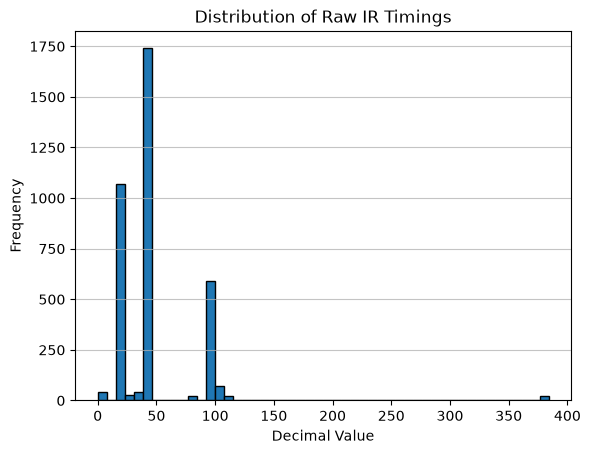

In [63]:
plt.hist(all_dec_codes, bins=50, edgecolor='black')
plt.title("Distribution of Raw IR Timings")
plt.xlabel("Decimal Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

We can observe some clustering around `20`, `40`, `100`. 

The header and final trailing space are included in this view. Their values are structurally different from the payload timings, so they appear as outliers and obscure the distribution of the repeated mark/space pairs.

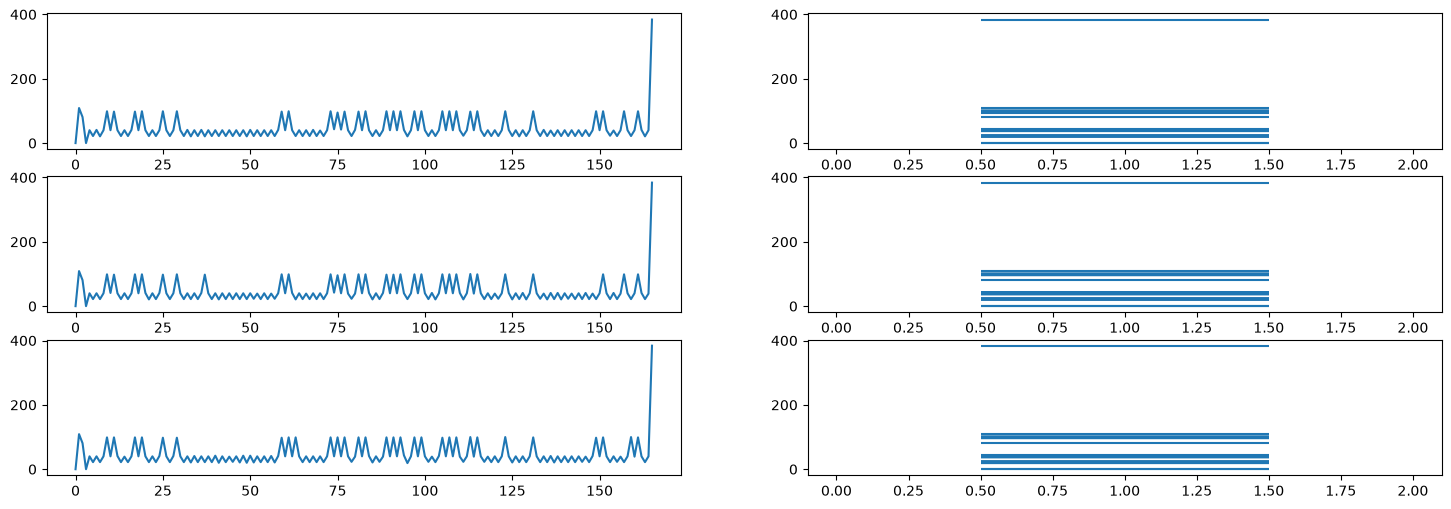

In [64]:
idx_selection = [0, 1, 2]

fig, axes = plt.subplots(len(idx_selection), 2, figsize=(18, 6))

for idx in idx_selection:
    decimal_values = pronto_codes[idx]['dec']
    axes[idx][0].plot(decimal_values, label=pronto_codes[idx]['label'])
    axes[idx][1].eventplot(decimal_values, orientation='vertical', label=pronto_codes[idx]['label'])

For the remaining timing analysis, we will exclude the four-word Pronto header and the final mark/long-space pair from each frame. This leaves 160 timing words, or 80 mark/space pairs, per capture.

This is an analytical normalization step only: the original frames remain unchanged in `raw`.

In [65]:
# Remove the header and footer
for code in pronto_codes:
    code['hex'] = code['hex'][4:-2]
    code['dec'] = code['dec'][4:-2]

In [66]:
print(f"len(hex): {len(pronto_codes[0]['hex'])}")
print(f"len(dec): {len(pronto_codes[0]['dec'])}")

len(hex): 160
len(dec): 160


Let redo the frequency distribution analysis

In [67]:
all_hex_codes = []
all_dec_codes = []
for code in pronto_codes:
    all_hex_codes.extend(code["hex"])
    all_dec_codes.extend(code["dec"])



In [68]:
hex_counts = Counter(all_hex_codes)
hex_counts

Counter({'0028': 1138,
         '0016': 718,
         '0063': 422,
         '0029': 342,
         '0015': 200,
         '0027': 199,
         '0062': 147,
         '0017': 128,
         '0064': 58,
         '002A': 33,
         '0026': 33,
         '0018': 23,
         '0014': 20,
         '0061': 17,
         '0065': 11,
         '002B': 6,
         '0025': 6,
         '005F': 3,
         '0060': 3,
         '0019': 3,
         '0013': 2,
         '0024': 2,
         '0066': 2,
         '001B': 1,
         '0067': 1,
         '0023': 1,
         '001A': 1})

In [69]:
dec_counts = Counter(all_dec_codes)
dec_counts

Counter({40: 1138,
         22: 718,
         99: 422,
         41: 342,
         21: 200,
         39: 199,
         98: 147,
         23: 128,
         100: 58,
         42: 33,
         38: 33,
         24: 23,
         20: 20,
         97: 17,
         101: 11,
         43: 6,
         37: 6,
         95: 3,
         96: 3,
         25: 3,
         19: 2,
         36: 2,
         102: 2,
         27: 1,
         103: 1,
         35: 1,
         26: 1})

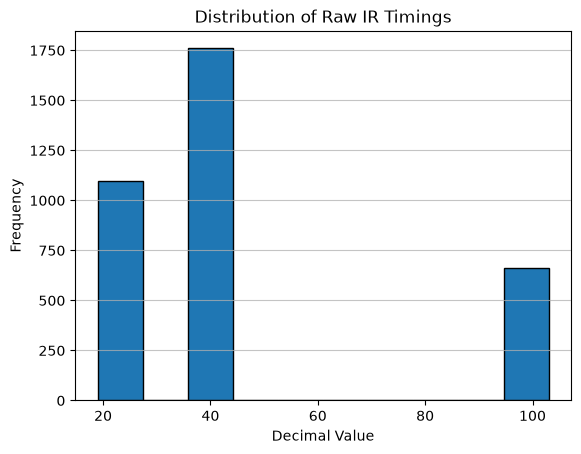

In [70]:
plt.hist(all_dec_codes, bins=10, edgecolor='black')
plt.title("Distribution of Raw IR Timings")
plt.xlabel("Decimal Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

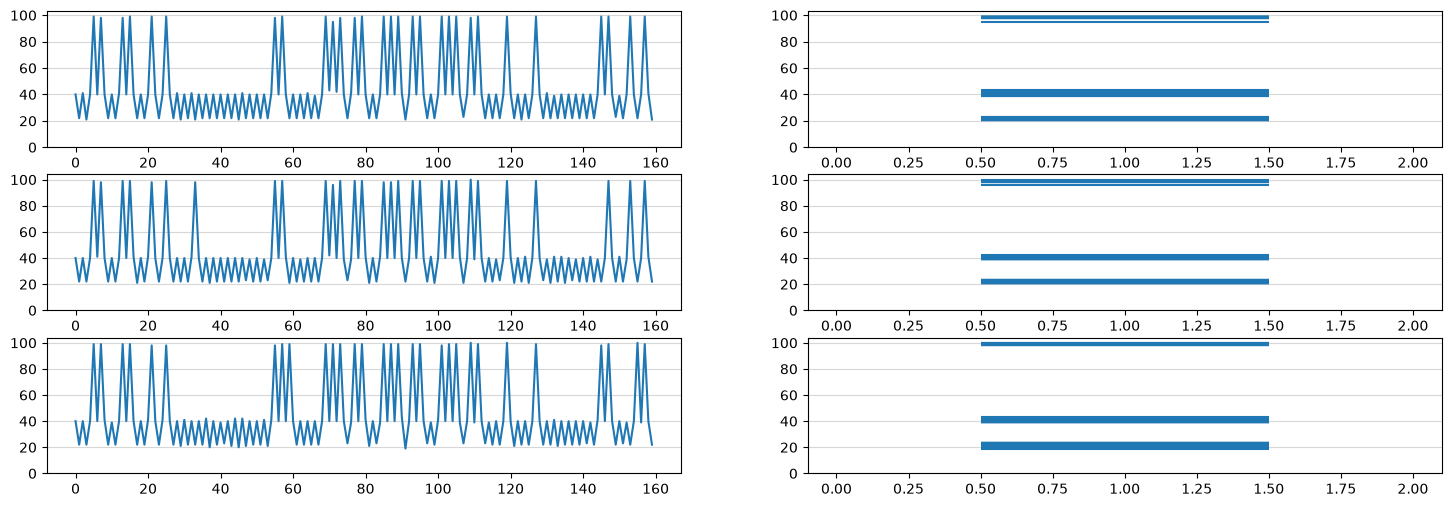

In [71]:
idx_selection = [0, 1, 2]

fig, axes = plt.subplots(len(idx_selection), 2, figsize=(18, 6))

for idx in idx_selection:
    decimal_values = pronto_codes[idx]['dec']
    axes[idx][0].plot(decimal_values, label=pronto_codes[idx]['label'])
    axes[idx][1].eventplot(decimal_values, orientation='vertical', label=pronto_codes[idx]['label'])
    axes[idx][0].set_yticks(range(0, 120, 20))
    axes[idx][1].set_yticks(range(0, 120, 20))
    axes[idx][0].grid(axis='y', alpha=0.5)
    axes[idx][1].grid(axis='y', alpha=0.5)

Much better. We can clearly see 3 bands clustered around `22`, `42` and `98`.

Without the framing values, the timing distribution resolves into three clear bands. The next step is to determine whether these bands correspond to a short space, a mark, and a long space.

### Mark and Space Positions

Each normalized payload alternates mark and space durations, beginning with a mark. Split the even and odd positions across all frames to test whether one timing band is consistently used for marks while the other two occur only in spaces.

Marks: 1760 values, range 35 to 43
Spaces: 1760 values, range 19 to 103


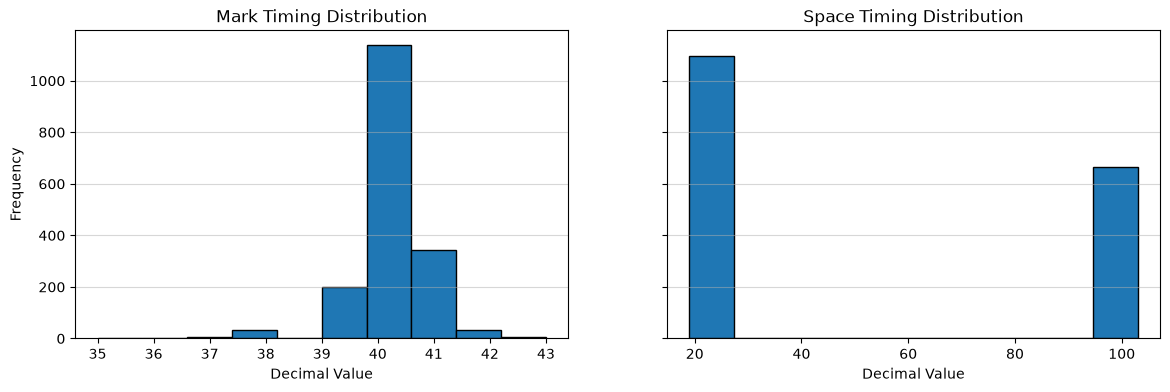

In [72]:
mark_values = [value for code in pronto_codes for value in code['dec'][::2]]
space_values = [value for code in pronto_codes for value in code['dec'][1::2]]

print(f"Marks: {len(mark_values)} values, range {min(mark_values)} to {max(mark_values)}")
print(f"Spaces: {len(space_values)} values, range {min(space_values)} to {max(space_values)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].hist(mark_values, bins=10, edgecolor='black')
axes[0].set_title('Mark Timing Distribution')
axes[0].set_xlabel('Decimal Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.5)

axes[1].hist(space_values, bins=10, edgecolor='black')
axes[1].set_title('Space Timing Distribution')
axes[1].set_xlabel('Decimal Value')
axes[1].grid(axis='y', alpha=0.5)

plt.show()

The mark positions form the middle timing band near `0x28`. The space positions form the short and long bands near `0x16` and `0x63`. This positional separation supports the pulse-distance modulation hypothesis: a nearly constant mark followed by a short or long space.

### Clustering the Frequencies

Visual inspection of the histogram reveals three distinct clusters. This aligns perfectly with how **Pulse Distance Modulation (PDM)** works in IR protocols:
1. A constant **Mark** (IR LED on).
2. A short **Space** representing a binary `0`.
3. A long **Space** representing a binary `1`.

In [73]:
import random

In [74]:
def kmeans(data: list[int], k: int = 3, max_iterations: int = 1000):
    """K-Means clustering implementation"""

    # Pick k unique random points as the starting centroids
    unique_data = list(set(data))

    # If we don't have enough points, just return what we have
    if len(unique_data) < k:
        return sorted(unique_data), {c: [c] for c in unique_data}

    # Pick k centroid randomly from the dataset
    centroids = random.sample(unique_data, k)

    clusters = {}
    for _ in range(max_iterations):
        # Create empty buckets for this iteration
        clusters = {c: [] for c in centroids}

        # Assign each data point to the closest centroid
        for point in data:
            nearest_centroid = min(centroids, key=lambda c: abs(c - point))
            clusters[nearest_centroid].append(point)

        # Calculate the new mean for each cluster
        new_centroids = []
        for c in centroids:
            if clusters[c]: # Avoid division by 0
                new_mean = sum(clusters[c]) / len(clusters[c])
                new_centroids.append(new_mean)
            else:
                new_centroids.append(c)

        # Convergence: Stop if centroids haven't moved
        if set(centroids) == set(new_centroids):
            break

        # Update the centroids for the next iteration
        centroids = new_centroids

    # Sort centroids so they are always ordered lowest to highest
    centroids.sort()

    # Re-key the clusters dictionary with the sorted centroids
    sorted_clusters = {c: clusters[c] for c in centroids}

    return [c for c in centroids], sorted_clusters

In [75]:
centroids, clusters = kmeans(all_dec_codes, k = 3)

print(f"Discovered Centroids: {centroids}\n")
for c in centroids:
    min_val = min(clusters[c])
    max_val = max(clusters[c])
    count = len(clusters[c])
    print(f"Center {round(c)} ({hex(round(c))}) | Count: {count:>4} | Range: {min_val} ({hex(min_val)}) to {max_val} ({hex(max_val)})")

Discovered Centroids: [21.9507299270073, 40.07386363636363, 98.83132530120481]

Center 22 (0x16) | Count: 1096 | Range: 19 (0x13) to 27 (0x1b)
Center 40 (0x28) | Count: 1760 | Range: 35 (0x23) to 43 (0x2b)
Center 99 (0x63) | Count:  664 | Range: 95 (0x5f) to 103 (0x67)


The IR Protocol follows **Pulse Distance Modulation** and has an alternating Mark-Space sequence. Here we can observe that `41` appears 640 times which is the sum of `400` (for `21`) and `240` (for `98`). Since these datapoints are in pairs, `41` is the mark value while `21` (short-space) and `98` (long-space) would signify the bits.

## Binarization

Use the midpoint between the short-space and mark clusters as the upper boundary for `0`, and the midpoint between the mark and long-space clusters as the lower boundary for `1`.

Only space positions are classified. Marks are structural timing elements and do not encode a bit in this pulse-distance interpretation.

In [76]:
# Calculate the thresholds using the centroids
midpoint_low = (centroids[0] + centroids[1]) / 2
midpoint_high = (centroids[1] + centroids[2]) / 2

print(f"Threshold for 0 (Short Space): < {midpoint_low:.2f}")
print(f"Threshold for 1 (Long Space): > {midpoint_high:.2f}\n")

Threshold for 0 (Short Space): < 31.01
Threshold for 1 (Long Space): > 69.45



In [77]:
for code in pronto_codes:
    bits = []

    for space in code['dec'][1::2]:
        if space < midpoint_low:
            bits.append(0)
        elif space > midpoint_high:
            bits.append(1)
        else:
            raise ValueError(f"Unclassified space timing in {code['label']}: {space}")

    code['bits'] = bits

In [78]:
_bits = "".join([str(b) for b in pronto_codes[0]['bits']])
_bits

'00110011001010000000000000011000001110110011101100111011000100010000000011001010'

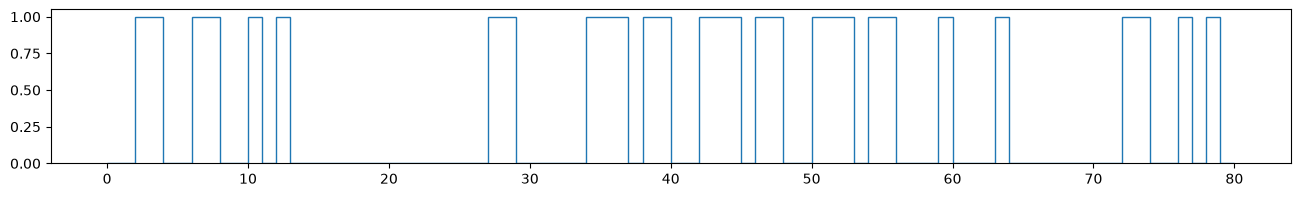

In [79]:
plt.figure(figsize=(16, 2))
plt.stairs(pronto_codes[0]['bits'])

In [80]:
len(_bits)

80

80 bits matches with the sequence length specified in the header and neatly specify 10 bytes of information.

## Bytes

Group the 80-bit sequence into ten consecutive 8-bit values, preserving transmission order. Bytes provide a practical unit for comparing captures: a controlled remote action may change one field while leaving the rest of the frame unchanged.

No byte meaning is assumed at this stage. The following comparison work will test which bytes vary with power, temperature, fan speed, mode, and switches.

In [81]:
for code in pronto_codes:
    code['bytes'] = []
    code['byteval'] = []
    for i in range(10):
        byte = "".join(str(b) for b in code['bits'][8*i:8*(i+1)])
        code['bytes'].append(byte)
        code['byteval'].append(int(byte, 2))

pronto_codes[0]['bytes']

['00110011',
 '00101000',
 '00000000',
 '00011000',
 '00111011',
 '00111011',
 '00111011',
 '00010001',
 '00000000',
 '11001010']

In [82]:
pronto_codes[0]['byteval']

[51, 40, 0, 24, 59, 59, 59, 17, 0, 202]

In [83]:
def get_code_by_label(label: str) -> dict:
    """Helper function to retrieve a pronto code by its label"""
    for code in pronto_codes:
        if code['label'] == label:
            return code
    raise KeyError(f"No Pronto code found with label: {label}")

In [84]:
from IPython.display import display, HTML

In [85]:
byte_comparision_table = ""
byte_comparision_table += "<table>"

byte_comparision_table += "<tr><th>Label</th>"

for column in range(10):
    byte_comparision_table += f"<th>Byte {column}</th><th>Val {column}</th>"

byte_comparision_table += "</tr>"

for row in pronto_codes:
    byte_comparision_table += f"<tr><td>{row['label']}</td>"
    for byte, val in zip(row['bytes'], row['byteval']):
        byte_comparision_table += f"<td>{byte}</td><td>{val}</td>"
    byte_comparision_table += "</tr>"

byte_comparision_table += "</table>"

display(HTML(byte_comparision_table))

Label,Byte 0,Val 0,Byte 1,Val 1,Byte 2,Val 2,Byte 3,Val 3,Byte 4,Val 4,Byte 5,Val 5,Byte 6,Val 6,Byte 7,Val 7,Byte 8,Val 8,Byte 9,Val 9
__OFF,00110011,51,00101000,40,00000000,0,00011000,24,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,11001010,202
__ON,00110011,51,00101000,40,10000000,128,00011000,24,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01001010,74
_PWR_OFF-28,00110011,51,00101000,40,00000000,0,00011100,28,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,11000110,198
_PWR_ON-28,00110011,51,00101000,40,10000000,128,00011100,28,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01000110,70
_TEMP_17-to-16_CH,00110011,51,00101000,40,10000000,128,00010000,16,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01010010,82
_TEMP_24-to-25_CH,00110011,51,00101000,40,10000000,128,00011001,25,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01001001,73
_TEMP_25-to-26_CH,00110011,51,00101000,40,10000000,128,00011010,26,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01001000,72
_TEMP_26-to-27_CH,00110011,51,00101000,40,10000000,128,00011011,27,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01000111,71
_TEMP_27-to-26_CH,00110011,51,00101000,40,10000000,128,00011010,26,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01001000,72
FAN_16C_Auto,00110011,51,11101000,232,10000000,128,00010000,16,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,10010010,146


The table makes it possible to compare frames at the byte level before assigning any field meanings. The next section uses controlled capture pairs to identify which bytes change with a single remote action.

Any apparent relationship is a hypothesis until it is supported by multiple controlled comparisons and, later, a synthesized transmission.

Byte 3 seems to directly map to the **Temperature** value. Byte 2 looks like its the **Power** state of the AC. Byte 9 is possibly the checksum.

---

## Diff Analysis

The byte table shows where captures differ, but controlled comparisons make those differences easier to interpret.

Each comparison below selects captures that differ by one known remote action where possible. Changed bytes are highlighted; unchanged bytes provide context for identifying state fields and for distinguishing command data from values that may vary between otherwise similar frames.

A changed byte is evidence of correlation, not proof of its meaning. Interpret each result alongside the known starting state, action performed, and resulting AC state.

In [86]:
def diff(*labels):
    """Compare two or more pronto codes by their labels"""
    
    if len(labels) < 2:
        print("Provide at least two labels to compare")
        return

    codes = [get_code_by_label(label) for label in labels]
    missing_labels = [label for label, code in zip(labels, codes) if not code]
    if missing_labels:
        print(f"Labels not found: {', '.join(missing_labels)}")
        return

    diff_table = "<table>"
    diff_table += "<tr><th>Byte</th>"
    for label in labels:
        diff_table += f"<th>{label}</th>"
    diff_table += "</tr>"

    for byte_index in range(10):
        byte_values = [code['bytes'][byte_index] for code in codes]
        has_difference = len(set(byte_values)) > 1

        diff_table += f"<tr><td>Byte {byte_index}</td>"
        for code, byte_value in zip(codes, byte_values):
            value = code['byteval'][byte_index]
            style = " style='background-color: #ffeeee'" if has_difference else ""
            diff_table += f"<td{style}>{byte_value}<br><small>{value}</small></td>"
        diff_table += "</tr>"

    diff_table += "</table>"
    display(HTML(diff_table))

In [87]:
diff("__OFF", "__ON")

Byte,__OFF,__ON
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,000000000,10000000128
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,11001010202,0100101074


Comparing `__OFF` and `__ON` changes only bytes 2 and 9.

Byte 2 changes from `00000000` (`0`) to `10000000` (`128`). The only changed bit is its most-significant bit, which strongly correlates with the captured power state: clear for OFF and set for ON.

Byte 9 also changes with the power state. Its purpose is not yet known, but its dependence on the other frame contents makes it a candidate checksum or integrity byte. This requires testing against additional controlled captures.

In [88]:
diff("__ON", "_TEMP_24-to-25_CH")

Byte,__ON,_TEMP_24-to-25_CH
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000000128
Byte 3,0001100024,0001100125
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100101074,0100100173


Starting from the `__ON` baseline, raising the set temperature from 24 to 25 changes only bytes 3 and 9.

Byte 3 moves from 24 to 25, matching the new set temperature. This is the first direct evidence that byte 3 encodes the set temperature.

Byte 9 changes from 74 to 73. As in the power comparison, it shifts whenever another byte changes, which is consistent with an integrity or checksum field.

In [89]:
diff("_TEMP_24-to-25_CH", "_TEMP_25-to-26_CH", "_TEMP_26-to-27_CH", "_TEMP_27-to-26_CH", "_TEMP_17-to-16_CH")

Byte,_TEMP_24-to-25_CH,_TEMP_25-to-26_CH,_TEMP_26-to-27_CH,_TEMP_27-to-26_CH,_TEMP_17-to-16_CH
Byte 0,0011001151,0011001151,0011001151,0011001151,0011001151
Byte 1,0010100040,0010100040,0010100040,0010100040,0010100040
Byte 2,10000000128,10000000128,10000000128,10000000128,10000000128
Byte 3,0001100125,0001101026,0001101127,0001101026,0001000016
Byte 4,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 5,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 6,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 7,0001000117,0001000117,0001000117,0001000117,0001000117
Byte 8,000000000,000000000,000000000,000000000,000000000
Byte 9,0100100173,0100100072,0100011171,0100100072,0101001082


Across five temperature transitions, byte 3 again matches the set temperature exactly: 25, 26, 27, 26, and 16.

Byte 9 also changes with temperature, but holds the same value when the temperature is unchanged (`26` appears twice with byte 9 = 72 in both frames). This dependence on other frame contents is consistent with an integrity or checksum field. Its exact relationship to the rest of the frame is not yet established.

No other bytes differ across these captures.
Notes:
- Byte 3: 25 → 26 → 27 → 26 → 16, mirroring the reported set temperatures exactly.
- Byte 9: 73 → 72 → 71 → 72 → 82, tracking temperature while power is ON.
- Bytes 0, 1, 2, 4–8 are constant here (51, 40, 128, 59, 59, 59, 17, 0).

In [90]:
diff("_TEMP_26-to-27_CH", "_TEMP_27-to-26_CH")

Byte,_TEMP_26-to-27_CH,_TEMP_27-to-26_CH
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000000128
Byte 3,0001101127,0001101026
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100011171,0100100072


Raising the temperature from 26 to 27 and then lowering it back to 26 restores byte 3 to 26 and byte 9 to 72.

Both values are identical to the earlier `25-to-26` capture (byte 3 = 26, byte 9 = 72). The frame therefore encodes the resulting set temperature, not the button press: separate captures of the same state produce identical bytes.

Byte 9 continues to track byte 3, remaining consistent with an integrity or checksum byte.

Across all temperature comparisons, byte 3 always equals the resulting set temperature, including after a round-trip back to the starting value. Byte 3 is the temperature field.

Byte 9 changes whenever byte 3 changes and is identical whenever byte 3 is identical. Its dependence on the rest of the frame is consistent with a checksum or integrity byte, but its formula is not yet known.

In [91]:
diff('_PWR_OFF-28', '_PWR_ON-28', '__OFF', '__ON')

Byte,_PWR_OFF-28,_PWR_ON-28,__OFF,__ON
Byte 0,0011001151,0011001151,0011001151,0011001151
Byte 1,0010100040,0010100040,0010100040,0010100040
Byte 2,000000000,10000000128,000000000,10000000128
Byte 3,0001110028,0001110028,0001100024,0001100024
Byte 4,0011101159,0011101159,0011101159,0011101159
Byte 5,0011101159,0011101159,0011101159,0011101159
Byte 6,0011101159,0011101159,0011101159,0011101159
Byte 7,0001000117,0001000117,0001000117,0001000117
Byte 8,000000000,000000000,000000000,000000000
Byte 9,11000110198,0100011070,11001010202,0100101074


Using our knowledge of the temperature byte, we can conclude using the above diff that the Power state is encoded in byte 2 and is independent. i.e. It doesn't matter what the temperature is, the power state is always encoded in byte 2. Byte 9 is a checksum or integrity byte that depends on the other bytes in the frame.

In [92]:
diff("FAN_16C_Auto", "FAN_16C_Low", "FAN_16C_Med", "FAN_16C_High", "_TEMP_17-to-16_CH")

Byte,FAN_16C_Auto,FAN_16C_Low,FAN_16C_Med,FAN_16C_High,_TEMP_17-to-16_CH
Byte 0,0011001151,0011001151,0011001151,0011001151,0011001151
Byte 1,11101000232,10001000136,0100100072,0010100040,0010100040
Byte 2,10000000128,10000000128,10000000128,10000000128,10000000128
Byte 3,0001000016,0001000016,0001000016,0001000016,0001000016
Byte 4,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 5,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 6,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 7,0001000117,0001000117,0001000117,0001000117,0001000117
Byte 8,000000000,000000000,000000000,000000000,000000000
Byte 9,10010010146,11110010242,0011001050,0101001082,0101001082


At a constant temperature (16 °C), changing only the fan speed changes bytes 1 and 9 and nothing else.

Byte 1 encodes the fan speed: Auto = `11101000` (232), Low = `10001000` (136), Med = `01001000` (72), High = `00101000` (40). The low three bits stay `000`; the remaining bits distinguish the four speeds. The `_TEMP_17-to-16_CH` reference has byte 1 = `00101000`, matching the High capture.

Byte 9 changes with byte 1, again consistent with the integrity or checksum byte. It does not reveal the fan speed itself; only byte 1 does.

In [93]:
diff('MODE_CH_21', 'MODE_DL_24', 'MODE_SA_23', 'MODE_FH_00')

Byte,MODE_CH_21,MODE_DL_24,MODE_SA_23,MODE_FH_00
Byte 0,0011001151,0011001151,0011001151,0011001151
Byte 1,0010100040,10000100132,11100010226,0010000133
Byte 2,10000000128,10000000128,10000000128,10000000128
Byte 3,0001010121,0001100024,0001011123,0001011123
Byte 4,0011101159,0011101159,0011101159,0011101159
Byte 5,0011101159,0011101159,0011101159,0011101159
Byte 6,0011101159,0011101159,0011101159,0011101159
Byte 7,0001000117,0001000117,0001000117,0001000117
Byte 8,000000000,000000000,000000000,000000000
Byte 9,0100110177,11101110238,10010001145,0101001082


- **Cool**: Full Control
- **Drop**: No Temperature or Fan Control or Turbo. Fixed at 24 Drop Fan Low,
- **Sun**: No response from my AC. Can change temp and fan speed but does nothing. Defaults to 23 Fan Auto. No Turbo Mode though.
- **Fan**: No temperature. Fan speed control only. No Fan Auto. No Turbo.

The four mode captures differ in bytes 1, 3, and 9.

Byte 1 changes again: Cool `00101000`, Drop `10000100`, Sun `11100010`, Fan `00100001`. Mode and fan-speed bits share this byte, so changing mode can move the same bits that encode fan speed — consistent with the behaviour notes: Drop is fixed to a low fan, Fan has no Auto, and Sun accepts fan changes that do nothing.

Byte 3 is the set temperature (21, 24, 23, 23), matching each mode's reported default.

Byte 9 continues to track the other changes, as expected for the integrity or checksum byte.

Byte 1 alone does not identify the mode; the same bits also carry fan speed and mode-specific defaults.

In [94]:
diff("__ON", "SWITCH_HSwing")

Byte,__ON,SWITCH_HSwing
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000000128
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,0001000016
Byte 9,0100101074,0011101058


Horizontal swing changes byte 8 from `00000000` (0) to `00010000` (16) and updates byte 9. No other byte changes. Byte 8 carries the horizontal-swing state.

In [95]:
diff("__ON", "SWITCH_VSwing")

Byte,__ON,SWITCH_VSwing
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000111135
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100101074,0100001167


Vertical swing changes byte 2 from `10000000` (128) to `10000111` (135) and updates byte 9. The power bit (bit 7) stays set; bits 0-2 are added. Vertical swing lives in the low bits of byte 2, the same byte that carries the power bit.

In [96]:
diff("__ON", "SWITCH_EcoSaver")

Byte,__ON,SWITCH_EcoSaver
Byte 0,0011001151,0011001151
Byte 1,0010100040,0100100072
Byte 2,10000000128,10000000128
Byte 3,0001100024,0101100088
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100101074,11101010234


EcoSaver affects more than one field. The AC also switches to a Medium fan, so byte 1 moves to `01001000` (72), the same value seen in the Medium fan capture, this is the fan-speed field, not a new flag.

Byte 3 moves from `00011000` (24) to `01011000` (88). Decomposing with the temperature field: the low bits still read 24 and bit 6 (value 64) is newly set. The set temperature is unchanged; the eco state is encoded as bit 6 of byte 3.


In [97]:
diff("__ON", "SWITCH_Lamp")

Byte,__ON,SWITCH_Lamp
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000000128
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,0010000032
Byte 9,0100101074,0010101042


The lamp changes byte 8 from `00000000` (0) to `00100000` (32) and updates byte 9. Horizontal swing set bit 4 of byte 8; the lamp sets bit 5. Byte 8 is a flag byte for both toggles.

In [98]:
diff("__ON", "SWITCH_Turbo")

Byte,__ON,SWITCH_Turbo
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10100000160
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100101074,0010101042


Turbo changes byte 2 from `10000000` (128) to `10100000` (160) and updates byte 9. The power bit stays set; bit 5 is added.

Vertical swing added bits 0-2 to byte 2 and Turbo adds bit 5. Byte 2 carries the power bit plus feature flags.

## Checksum / Integrity Byte

In every comparison, byte 9 changes whenever any other byte changes. It is identical whenever the other bytes are identical. This is consistent with a checksum or integrity byte, but we still need to establish its exact relationship to the rest of the frame.

let's start by comparing the `__ON` and `__OFF` captures. The only changed byte is byte 2, which flips from `00000000` (0) to `10000000` (128). Byte 9 changes from `11001010` (202) to `01001001` (74).

In [99]:
on = get_code_by_label("__ON")['byteval']
on

[51, 40, 128, 24, 59, 59, 59, 17, 0, 74]

In [100]:
off = get_code_by_label("__OFF")['byteval']
off

[51, 40, 0, 24, 59, 59, 59, 17, 0, 202]

In [101]:
on[2], off[2], off[2] - on[2], on[2] ^ off[2], on[2] & off[2], on[2] | off[2]

(128, 0, -128, 128, 0, 128)

Byte 9 reacts with the same magnitude but the opposite sign: −128.

In [102]:
on[9], off[9], on[9] - off[9], on[9] ^ off[9], on[9] & off[9], on[9] | off[9]

(74, 202, -128, 128, 74, 202)

Looking at subtraction, XOR, AND, and OR operations between the two bytes, we can see that the difference is `-128` which is consistent with the change in byte 2 from 0 to 128. This suggests that byte 9 is a checksum or integrity byte that depends on the other bytes in the frame.

In [103]:
temp_24 = get_code_by_label("_TEMP_24-to-25_CH")['byteval']
temp_25 = get_code_by_label("_TEMP_25-to-26_CH")['byteval']

In [104]:
temp_24[3], temp_25[3], temp_25[3] - temp_24[3], temp_24[3] ^ temp_25[3], temp_24[3] & temp_25[3], temp_24[3] | temp_25[3]

(25, 26, 1, 3, 24, 27)

In [105]:
temp_24[9], temp_25[9], temp_25[9] - temp_24[9], temp_24[9] ^ temp_25[9], temp_24[9] & temp_25[9], temp_24[9] | temp_25[9]

(73, 72, -1, 1, 72, 73)

In [106]:
temp_26 = get_code_by_label("_TEMP_26-to-27_CH")['byteval']
temp_25[9], temp_26[9], temp_26[9] - temp_25[9], temp_26[9] ^ temp_25[9], temp_26[9] & temp_25[9], temp_26[9] | temp_25[9]

(72, 71, -1, 15, 64, 79)

Every point increase in temperature (+1) corresponds to a decrease of 1 (-1) in the checksum byte.

In the case of power, the checksum byte changes from 202 to 74, which is a difference of -128. This is consistent with the change in byte 2 from 0 to 128.

In [107]:
sum(on), sum(off), sum(temp_24), sum(temp_25), sum(temp_26)

(511, 511, 511, 511, 511)

Interestingly, all of them add up to 511

In [108]:
sum(on[:-1]), sum(off[:-1]), sum(temp_24[:-1]), sum(temp_25[:-1]), sum(temp_26[:-1])

(437, 309, 438, 439, 440)

In [109]:
on[9], off[9], temp_24[9], temp_25[9], temp_26[9]

(74, 202, 73, 72, 71)

In [110]:
sum(on[:-1]) + on[9], sum(off[:-1]) + off[9], sum(temp_24[:-1]) + temp_24[9], sum(temp_25[:-1]) + temp_25[9], sum(temp_26[:-1]) + temp_26[9]

(511, 511, 511, 511, 511)

So it looks like byte 9 is whatever is needed to hold the total sum of the other bytes in the frame to 511. This is consistent with the checksum or integrity byte hypothesis.

511 is awfully close to 512, maybe something to do with a % 256 operation. Let's check that.

In [111]:
sum(on[:-1]) % 256, sum(off[:-1]) % 256, sum(temp_24[:-1]) % 256, sum(temp_25[:-1]) % 256, sum(temp_26[:-1]) % 256

(181, 53, 182, 183, 184)

Not quite. Maybe one's complement?

In [112]:
255 - sum(on[:-1]) % 256, 255 - sum(off[:-1]) % 256, 255 - sum(temp_24[:-1]) % 256, 255 - sum(temp_25[:-1]) % 256, 255 - sum(temp_26[:-1]) % 256

(74, 202, 73, 72, 71)

Bingo! The checksum byte is the one's complement of the sum of the other bytes in the frame. This means that if you add up all the bytes in the frame (excluding the checksum byte) and then take the one's complement of that sum, you will get the value of the checksum byte.

In [113]:
def checksum(byte_values):
    """Calculate the checksum byte for a given list of byte values"""
    total_sum = sum(byte_values[:-1])  # Exclude the checksum byte itself
    checksum = 255 - (total_sum % 256)  # One's complement of the sum
    return checksum

In [114]:
# Validate the checksum for each code
for code in pronto_codes:
    calculated_checksum = checksum(code['byteval'])
    actual_checksum = code['byteval'][-1]
    if calculated_checksum != actual_checksum:
        print(f"Checksum mismatch for {code['label']}: calculated {calculated_checksum}, actual {actual_checksum}")
    else:
        print(f"Checksum valid for {code['label']}: {actual_checksum}")

Checksum valid for __OFF: 202
Checksum valid for __ON: 74
Checksum valid for _PWR_OFF-28: 198
Checksum valid for _PWR_ON-28: 70
Checksum valid for _TEMP_17-to-16_CH: 82
Checksum valid for _TEMP_24-to-25_CH: 73
Checksum valid for _TEMP_25-to-26_CH: 72
Checksum valid for _TEMP_26-to-27_CH: 71
Checksum valid for _TEMP_27-to-26_CH: 72
Checksum valid for FAN_16C_Auto: 146
Checksum valid for FAN_16C_High: 82
Checksum valid for FAN_16C_Low: 242
Checksum valid for FAN_16C_Med: 50
Checksum valid for MODE_CH_21: 77
Checksum valid for MODE_DL_24: 238
Checksum valid for MODE_FH_00: 82
Checksum valid for MODE_SA_23: 145
Checksum valid for SWITCH_EcoSaver: 234
Checksum valid for SWITCH_HSwing: 58
Checksum valid for SWITCH_Lamp: 42
Checksum valid for SWITCH_Turbo: 42
Checksum valid for SWITCH_VSwing: 67


---

## Conclusions

Observations currently cover power, temperature, fan speed, mode, and feature toggles. Skipped observations for timer, sleep, etc. for now.

**Physical Layer**: Frames are transmitted on a 38 kHz carrier using Pulse Distance Modulation (PDM): a constant mark separates each space, and the space length carries the data — short space = 0, long space = 1

**Frame Structure**: Each frame is 166 Pronto words: the 4-word header `0000 006D 0051 0000` followed by 81 mark/space burst pairs. The 80 payload spaces decode to ten bytes

**Byte map.** Bits are numbered 7 (MSB) to 0 (LSB). Derived from all 22 captures.

| Byte | Bits | Value(s) observed | Meaning |
|------|------|-------------------|---------|
| 0 | all | `00110011` (`0x33`) | Constant; role not established |
| 1 | 7–5 | `100` Low, `010` Medium, `001` High, `111` Auto | Fan speed (one-hot per speed; Auto sets all three) |
| 1 | 3–0 | `1000` Cool, `0100` Dry, `0010` Sun, `0001` Fan | Mode (one-hot; bit 4 not used) |
| 2 | 7 | `1` ON, `0` OFF | Power |
| 2 | 5 | `1` = Turbo | Turbo |
| 2 | 2–0 | `111` = vertical swing | Vertical swing (bits 0–2) |
| 3 | 4–0 | `00010000`–`00011100` (`0x10`–`0x1C`) | Set temperature, 16–28 °C direct value |
| 3 | 6 | `1` = EcoSaver | EcoSaver (adds `0x40`) |
| 4–6 | all | `00111011` (`0x3B`) | Constant; role not established |
| 7 | all | `00010001` (`0x11`) | Constant; role not established |
| 8 | 5 | `1` = lamp | Lamp |
| 8 | 4 | `1` = horizontal swing | Horizontal swing |
| 9 | — | one's-complement of sum | Checksum (see below) |

**Byte 1 detail.** Fan and mode are independent fields in the same byte:

| Capture | Byte 1 | Fan bits (7–5) | Mode bits (3–0) |
|---------|--------|----------------|-----------------|
| `FAN_16C_High` | `0x28` | `001` High | `1000` Cool |
| `FAN_16C_Med` | `0x48` | `010` Medium | `1000` Cool |
| `FAN_16C_Low` | `0x88` | `100` Low | `1000` Cool |
| `FAN_16C_Auto` | `0xE8` | `111` Auto | `1000` Cool |
| `MODE_CH_21` | `0x28` | `001` High | `1000` Cool |
| `MODE_DL_24` | `0x84` | `100` Low | `0100` Dry |
| `MODE_SA_23` | `0xE2` | `111` Auto | `0010` Sun |
| `MODE_FH_00` | `0x21` | `001` High | `0001` Fan |

**Checksum.** byte 9 = 255 − (sum of bytes 0–8, mod 256), i.e. the ten bytes always sum to 511. Verified against all 22 captures. It is a weak integrity check and must be recomputed when synthesizing frames.

**Encoding detail.** The temperature field confirms a direct mapping (24 → `0x18`, 25 → `0x19`, …), and separate captures of identical states produced identical frames, so the remote sends the resulting state, not the button press.